In [ ]:
import xarray as xr

ds = xr.open_dataset("ebfa72c1e9eb530b7c57f2e23f9a2f75.nc")



In [ ]:
import pandas as pd


In [ ]:
data1 = xr.open_dataset("data_stream-oper_stepType-instant.nc")



In [ ]:
no2df = pd.read_csv("India_NO2_2024.csv")


In [ ]:
no2df.columns

Index(['system:index', 'tropospheric_NO2_column_number_density', '.geo'], dtype='object')

In [ ]:
import pandas as pd
import json

no2df = pd.read_csv("India_NO2_2024.csv")

def extract_coords(geo_str):
    geo = json.loads(geo_str)
    lon, lat = geo["coordinates"]
    return pd.Series([lat, lon])

no2df[['latitude', 'longitude']] = no2df['.geo'].apply(extract_coords)

no2df = no2df.drop(columns=['.geo', 'system:index'])

no2df.head()

,tropospheric_NO2_column_number_density,latitude,longitude
0,0.000006,6.063628,68.047383
1,0.000007,6.063628,68.137214
2,0.000006,6.063628,68.227046
3,0.000006,6.063628,68.316877
4,0.000006,6.063628,68.406709


In [ ]:
cpcbdff = pd.read_csv("City_wise_raw_data_15Min_2024_Agartala_15Min.csv")
cpcbdff.head()

,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),...,MP-Xylene (µg/m³),AT (°C),RH (%),WS (m/s),WD (deg),RF (mm),TOT-RF (mm),SR (W/mt2),BP (mmHg),VWS (m/s)
0,2024-01-01 00:00:00,NaN,267.73,13.73,11.18,27.52,8.33,16.02,1.34,0.26,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
1,2024-01-01 00:15:00,NaN,266.50,14.20,10.61,27.62,8.69,15.96,1.33,0.19,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
2,2024-01-01 00:30:00,NaN,266.50,14.46,10.18,27.58,8.79,16.02,1.30,0.19,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
3,2024-01-01 00:45:00,NaN,266.50,14.52,10.22,27.68,8.22,16.08,1.28,0.31,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN
4,2024-01-01 01:00:00,NaN,298.77,14.09,10.41,27.31,8.16,15.99,1.26,0.36,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN


In [ ]:
import pandas as pd
import glob
import os

files = glob.glob("City_wise_raw_data_15Min_2024_*_15Min.csv")

dfs = []

for file in files:
    city = os.path.basename(file)\
        .replace("City_wise_raw_data_15Min_2024_", "")\
        .replace("_15Min.csv", "")

    df = pd.read_csv(file)

    df["City"] = city

    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

print(combined_df.shape)
combined_df.tail()

(983808, 26)


,Timestamp,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),...,AT (°C),RH (%),WS (m/s),WD (deg),RF (mm),TOT-RF (mm),SR (W/mt2),BP (mmHg),VWS (m/s),City
983803,2024-12-31 22:45:00,74.41,198.8,8.98,13.73,22.71,30.50,12.68,0.89,NaN,...,NaN,65.82,0.31,185.49,NaN,NaN,120.7,NaN,NaN,Amritsar
983804,2024-12-31 23:00:00,67.66,193.3,10.68,14.91,25.59,29.57,12.75,0.90,NaN,...,NaN,66.07,0.32,176.11,NaN,NaN,120.7,NaN,NaN,Amritsar
983805,2024-12-31 23:15:00,67.66,193.3,10.47,18.20,28.67,29.11,12.74,0.88,NaN,...,NaN,65.81,0.22,217.40,NaN,NaN,116.5,NaN,NaN,Amritsar
983806,2024-12-31 23:30:00,75.66,199.8,8.48,12.48,20.95,30.47,12.33,0.86,NaN,...,NaN,65.75,0.36,183.53,NaN,NaN,123.0,NaN,NaN,Amritsar
983807,2024-12-31 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Amritsar


In [ ]:
combined_df.to_csv("India_CPCB_2024.csv", index=False)

In [ ]:


#converting to daily dataset

combined_df['Timestamp'] = pd.to_datetime(combined_df['Timestamp'])

combined_df['Date'] = combined_df['Timestamp'].dt.date

daily_df = (
    combined_df
    .groupby(['City', 'Date'])
    .mean(numeric_only=True)
    .reset_index()
)

daily_df.head()

,City,Date,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),...,MP-Xylene (µg/m³),AT (°C),RH (%),WS (m/s),WD (deg),RF (mm),TOT-RF (mm),SR (W/mt2),BP (mmHg),VWS (m/s)
0,Agartala,2024-01-01,124.473000,252.816146,12.971354,12.558021,27.695104,8.624792,16.148854,1.423750,...,NaN,NaN,NaN,NaN,NaN,0.0,0.0,11.661146,NaN,NaN
1,Agartala,2024-01-02,104.852917,186.224792,4.489271,11.601354,15.771042,8.957187,16.167813,1.161667,...,NaN,NaN,74.390000,0.723333,300.836667,0.0,0.0,10.609375,750.0,NaN
2,Agartala,2024-01-03,78.468118,116.610000,8.511979,9.020521,18.834896,9.042159,16.638333,0.854687,...,NaN,NaN,73.597500,1.077500,290.515000,0.0,0.0,2.996875,750.0,NaN
3,Agartala,2024-01-04,93.959583,211.573696,16.547292,9.415521,29.710521,9.308542,18.209896,1.247604,...,NaN,NaN,91.783636,0.470000,142.625455,0.0,0.0,6.415417,750.0,NaN
4,Agartala,2024-01-05,71.468710,125.505054,12.169583,10.120521,24.551042,7.974062,18.203125,0.905104,...,NaN,NaN,88.677188,0.626146,167.252813,0.0,0.0,22.944583,750.0,NaN


In [ ]:


#saving the database 


In [ ]:
daily_df.to_csv("India_CPCB_Daily_2024.csv", index=False)

In [ ]:


# cleanining the dataset

daily_df.isnull().sum().sort_values(ascending=False)

O Xylene (µg/m³)       10248
Xylene (µg/m³)          7027
VWS (m/s)               6293
BP (mmHg)               3800
Toluene (µg/m³)         3159
Eth-Benzene (µg/m³)     2752
MP-Xylene (µg/m³)       2375
AT (°C)                 1786
RF (mm)                  995
Benzene (µg/m³)          902
NH3 (µg/m³)              753
TOT-RF (mm)              732
PM10 (µg/m³)             399
Ozone (µg/m³)            397
PM2.5 (µg/m³)            382
RH (%)                   376
NO (µg/m³)               376
NO2 (µg/m³)              376
NOx (ppb)                374
WS (m/s)                 369
WD (deg)                 369
SO2 (µg/m³)              342
SR (W/mt2)               310
CO (mg/m³)               267
City                       0
Date                       0
dtype: int64

In [ ]:
daily_df = daily_df.groupby('City').apply(
    lambda x: x.fillna(x.median(numeric_only=True))
).reset_index(drop=True)

/tmp/ipykernel_28209/127534387.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_df = daily_df.groupby('City').apply(


In [ ]:
daily_df.isnull().sum().sort_values(ascending=False).head(10)

O Xylene (µg/m³)       10248
Xylene (µg/m³)          6588
VWS (m/s)               6222
Toluene (µg/m³)         2928
BP (mmHg)               2928
Eth-Benzene (µg/m³)     1830
MP-Xylene (µg/m³)       1464
AT (°C)                 1098
TOT-RF (mm)              732
RF (mm)                  732
dtype: int64

In [ ]:
drop_cols = [
    'O Xylene (µg/m³)',
    'Xylene (µg/m³)',
    'Toluene (µg/m³)',
    'Eth-Benzene (µg/m³)',
    'MP-Xylene (µg/m³)',
    'VWS (m/s)'
]

daily_df = daily_df.drop(columns=drop_cols)

In [ ]:
features = [
    'NO2 (µg/m³)',
    'SO2 (µg/m³)',
    'CO (mg/m³)',
    'Ozone (µg/m³)',
    'AT (°C)',
    'RH (%)',
    'WS (m/s)',
    'RF (mm)',
    'BP (mmHg)'
]

target = 'PM2.5 (µg/m³)'

model_df = daily_df[features + [target]].dropna()

print(model_df.shape)

(6588, 10)


In [ ]:


# first model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("R² =", r2_score(y_test, pred))
print("MAE =", mean_absolute_error(y_test, pred))

R² = 0.6194721780855192
MAE = 10.195487975725916


In [ ]:
daily_df['Date'] = pd.to_datetime(daily_df['Date'])

daily_df['month'] = daily_df['Date'].dt.month
daily_df['dayofyear'] = daily_df['Date'].dt.dayofyear

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
daily_df['city_id'] = le.fit_transform(daily_df['City'])

In [ ]:
features = [
    'NO2 (µg/m³)',
    'SO2 (µg/m³)',
    'CO (mg/m³)',
    'Ozone (µg/m³)',
    'AT (°C)',
    'RH (%)',
    'WS (m/s)',
    'RF (mm)',
    'BP (mmHg)',
    'month',
    'dayofyear',
    'city_id'
]

In [ ]:
daily_df['Date'] = pd.to_datetime(daily_df['Date'])

daily_df['month'] = daily_df['Date'].dt.month
daily_df['dayofyear'] = daily_df['Date'].dt.dayofyear

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
daily_df['city_id'] = le.fit_transform(daily_df['City'])

In [ ]:
features = [
    'NO2 (µg/m³)',
    'SO2 (µg/m³)',
    'CO (mg/m³)',
    'Ozone (µg/m³)',
    'AT (°C)',
    'RH (%)',
    'WS (m/s)',
    'RF (mm)',
    'BP (mmHg)',
    'month',
    'dayofyear',
    'city_id'
]

target = 'PM2.5 (µg/m³)'

model_df = daily_df[features + [target]].dropna()

In [ ]:
print(model_df.columns)
print(model_df.shape)

Index(['NO2 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)', 'AT (°C)',
       'RH (%)', 'WS (m/s)', 'RF (mm)', 'BP (mmHg)', 'month', 'dayofyear',
       'city_id', 'PM2.5 (µg/m³)'],
      dtype='object')
(6588, 13)


In [ ]:
print(daily_df[['month','dayofyear','city_id']].head())

   month  dayofyear  city_id
0      1          1        0
1      1          2        0
2      1          3        0
3      1          4        0
4      1          5        0


In [ ]:


# first model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("R² =", r2_score(y_test, pred))
print("MAE =", mean_absolute_error(y_test, pred))

R² = 0.6741914018050921
MAE = 9.495178078602171


In [ ]:
list(data1.data_vars)

['u10', 'v10', 'd2m', 't2m', 'sp', 'blh']

In [ ]:
city_coords = {
    "Agartala": (23.8315, 91.2868),
    "Amaravati": (16.5062, 80.6480),
    "Amritsar": (31.6340, 74.8723),
    "Baddi": (30.9578, 76.7914),
    "Bengaluru": (12.9716, 77.5946),
    "Bhubaneswar": (20.2961, 85.8245),
    "Chandigarh": (30.7333, 76.7794),
    "Chennai": (13.0827, 80.2707),
    "Dehradun": (30.3165, 78.0322),
    "Delhi": (28.6139, 77.2090),
    "Gangtok": (27.3389, 88.6065),
    "Guwahati": (26.1445, 91.7362),
    "Gurugram": (28.4595, 77.0266),
    "Hyderabad": (17.3850, 78.4867),
    "Imphal": (24.8170, 93.9368),
    "Jaipur": (26.9124, 75.7873),
    "Kohima": (25.6751, 94.1086),
    "Kolkata": (22.5726, 88.3639),
    "Lucknow": (26.8467, 80.9462),
    "Mumbai": (19.0760, 72.8777),
    "Nagpur": (21.1458, 79.0882),
    "Naharlagun": (27.1047, 93.6956),
    "Patna": (25.5941, 85.1376),
    "Raipur": (21.2514, 81.6296),
    "Shillong": (25.5788, 91.8933),
    "Srinagar": (34.0837, 74.7973),
    "Thiruvananthapuram": (8.5241, 76.9366)
}

In [ ]:
era5_all = []

for city, (lat, lon) in city_coords.items():

    city_ds = data1.sel(
        latitude=lat,
        longitude=lon,
        method="nearest"
    )

    city_df = city_ds.to_dataframe().reset_index()

    city_daily = (
        city_df
        .groupby(city_df['valid_time'].dt.date)
        .agg({
            'u10':'mean',
            'v10':'mean',
            't2m':'mean',
            'd2m':'mean',
            'sp':'mean',
            'blh':'mean'
        })
        .reset_index()
    )

    city_daily['City'] = city

    era5_all.append(city_daily)

era5_df = pd.concat(era5_all, ignore_index=True)

In [ ]:
print(era5_df.shape)
era5_df.head()

(9882, 8)


,valid_time,u10,v10,t2m,d2m,sp,blh,City
0,2024-01-01,1.120132,-1.007381,291.896454,289.627075,101265.656250,259.643707,Agartala
1,2024-01-02,0.868599,-1.333759,291.284088,289.171783,101261.257812,335.341461,Agartala
2,2024-01-03,0.696434,-1.453186,290.016663,288.335083,101242.750000,273.161224,Agartala
3,2024-01-04,-0.081318,-1.032997,291.049805,288.491150,101254.601562,229.474350,Agartala
4,2024-01-05,0.067165,-1.771732,290.428223,288.435333,101326.648438,231.083969,Agartala


In [ ]:
era5_df.rename(
    columns={'valid_time':'Date'},
    inplace=True
)

era5_df['Date'] = pd.to_datetime(era5_df['Date'])
daily_df['Date'] = pd.to_datetime(daily_df['Date'])

In [ ]:
merged_df = daily_df.merge(
    era5_df,
    on=['City','Date'],
    how='left'
)

In [ ]:
print(merged_df.shape)

merged_df[
    ['City','Date','blh','u10','v10']
].head()

(10248, 29)


,City,Date,blh,u10,v10
0,Agartala,2024-01-01,259.643707,1.120132,-1.007381
1,Agartala,2024-01-02,335.341461,0.868599,-1.333759
2,Agartala,2024-01-03,273.161224,0.696434,-1.453186
3,Agartala,2024-01-04,229.474350,-0.081318,-1.032997
4,Agartala,2024-01-05,231.083969,0.067165,-1.771732


In [ ]:
print(merged_df.shape)
merged_df[['City','Date','blh']].head()

(10248, 29)


,City,Date,blh
0,Agartala,2024-01-01,259.643707
1,Agartala,2024-01-02,335.341461
2,Agartala,2024-01-03,273.161224
3,Agartala,2024-01-04,229.474350
4,Agartala,2024-01-05,231.083969


In [ ]:
features_era5 = [
    'NO2 (µg/m³)',
    'SO2 (µg/m³)',
    'CO (mg/m³)',
    'Ozone (µg/m³)',
    'AT (°C)',
    'RH (%)',
    'WS (m/s)',
    'RF (mm)',
    'BP (mmHg)',

    'month',
    'dayofyear',
    'city_id',

    'u10',
    'v10',
    't2m',
    'd2m',
    'sp',
    'blh'
]

target = 'PM2.5 (µg/m³)'

In [ ]:
model_df2 = merged_df[features_era5 + [target]].dropna()

print(model_df2.shape)

(6222, 19)


In [ ]:
print(features_era5)

['NO2 (µg/m³)', 'SO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)', 'AT (°C)', 'RH (%)', 'WS (m/s)', 'RF (mm)', 'BP (mmHg)', 'month', 'dayofyear', 'city_id', 'u10', 'v10', 't2m', 'd2m', 'sp', 'blh']


In [ ]:
merged_df[features_era5].isnull().sum().sort_values(ascending=False)

BP (mmHg)        2928
AT (°C)          1098
RF (mm)           732
d2m               366
blh               366
sp                366
t2m               366
v10               366
u10               366
NO2 (µg/m³)         0
SO2 (µg/m³)         0
month               0
Ozone (µg/m³)       0
RH (%)              0
CO (mg/m³)          0
WS (m/s)            0
dayofyear           0
city_id             0
dtype: int64

In [ ]:
print(model_df2.shape)
print(merged_df.shape)

(6222, 19)
(10248, 29)


In [ ]:

import joblib

joblib.dump(rf, "pm25_model.pkl")

print("Model saved")


Model saved


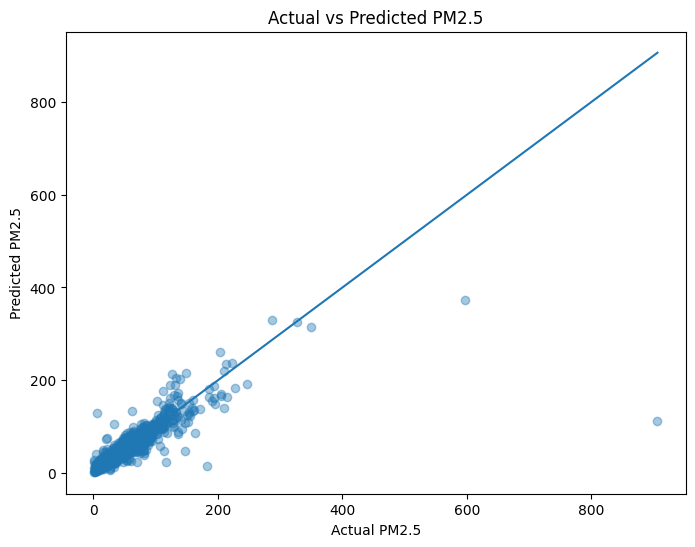

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted PM2.5")

plt.show()

In [ ]:
merged_df.to_csv(
    "india_pm25_era5_2024.csv",
    index=False
)

In [ ]:
import joblib

joblib.dump(
    rf,
    "pm25_random_forest.pkl"
)

['pm25_random_forest.pkl']

In [ ]:


fire_df = pd.read_csv("viirs-jpss1_2024_India.csv")

print(fire_df.columns)
fire_df.head()

Index(['latitude', 'longitude', 'bright_ti4', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'instrument', 'confidence', 'version',
       'bright_ti5', 'frp', 'daynight', 'type'],
      dtype='object')


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type
0,24.82792,93.75638,339.55,0.38,0.59,2024-01-01,613,N20,VIIRS,n,2,288.58,4.46,D,0
1,25.39434,91.32460,333.95,0.52,0.67,2024-01-01,613,N20,VIIRS,n,2,286.02,4.16,D,0
2,25.39488,91.32134,326.99,0.52,0.67,2024-01-01,613,N20,VIIRS,n,2,288.68,5.23,D,0
3,26.45587,91.93678,328.52,0.45,0.63,2024-01-01,614,N20,VIIRS,n,2,293.58,2.61,D,0
4,26.51382,91.82086,325.51,0.46,0.63,2024-01-01,614,N20,VIIRS,n,2,293.86,1.81,D,0


In [ ]:
fire_df['acq_date'] = pd.to_datetime(fire_df['acq_date'])

daily_fire = (
    fire_df.groupby('acq_date')
           .size()
           .reset_index(name='fire_count')
)

daily_fire.head()

,acq_date,fire_count
0,2024-01-01,1354
1,2024-01-02,1591
2,2024-01-03,1232
3,2024-01-04,966
4,2024-01-05,1097


In [ ]:
daily_fire.rename(
    columns={'acq_date':'Date'},
    inplace=True
)

daily_fire['Date'] = pd.to_datetime(daily_fire['Date'])

daily_fire.head()

,Date,fire_count
0,2024-01-01,1354
1,2024-01-02,1591
2,2024-01-03,1232
3,2024-01-04,966
4,2024-01-05,1097


In [ ]:
merged_df['Date'] = pd.to_datetime(merged_df['Date'])

In [ ]:
merged_df = merged_df.merge(
    daily_fire,
    on='Date',
    how='left'
)

merged_df['fire_count'] = merged_df['fire_count'].fillna(0)

print(merged_df.shape)
merged_df[['Date','fire_count']].head()

(10248, 30)


,Date,fire_count
0,2024-01-01,1354.0
1,2024-01-02,1591.0
2,2024-01-03,1232.0
3,2024-01-04,966.0
4,2024-01-05,1097.0


In [ ]:
features_fire = features_era5 + ['fire_count']


In [ ]:
model_df3 = merged_df[features_fire + [target]].dropna()


In [ ]:
merged_df = merged_df.sort_values(
    ['City','Date']
)

merged_df['pm25_lag1'] = (
    merged_df.groupby('City')['PM2.5 (µg/m³)']
    .shift(1)
)

merged_df[['City','Date','PM2.5 (µg/m³)','pm25_lag1']].head()

,City,Date,PM2.5 (µg/m³),pm25_lag1
0,Agartala,2024-01-01,124.473000,NaN
1,Agartala,2024-01-02,104.852917,124.473000
2,Agartala,2024-01-03,78.468118,104.852917
3,Agartala,2024-01-04,93.959583,78.468118
4,Agartala,2024-01-05,71.468710,93.959583


In [ ]:
merged_df['pm25_lag1'].isnull().sum()

np.int64(28)

In [ ]:
features_final = features_fire + ['pm25_lag1']

In [ ]:
model_df_final = merged_df[
    features_final + [target]
].dropna()

print(model_df_final.shape)

(6205, 21)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X = model_df_final[features_final]
y = model_df_final[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("R² =", r2_score(y_test, pred))
print("MAE =", mean_absolute_error(y_test, pred))

R² = 0.8046179227111999
MAE = 8.980153238895682


In [ ]:
import joblib

joblib.dump(rf, "pm25_prediction_model.pkl")

['pm25_prediction_model.pkl']

In [ ]:
joblib.dump(features_final, "features_final.pkl")

['features_final.pkl']

In [ ]:
merged_df[['City','city_id']].drop_duplicates().head(20)

,City,city_id
0,Agartala,0
366,Ahmedabad,1
732,Amaravati,2
1098,Amritsar,3
1464,Baddi,4
1830,Bengaluru,5
2196,Bhubaneswar,6
2562,Chandigarh,7
2928,Chennai,8
3294,Dehradun,9


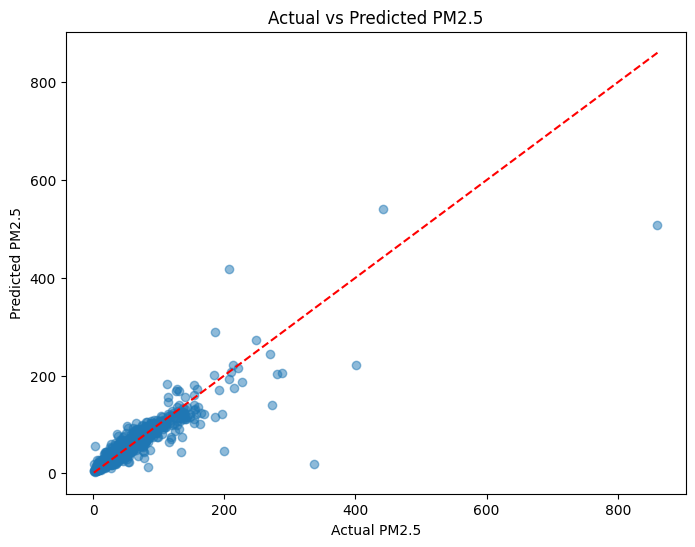

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted PM2.5")

plt.show()

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("R² =", r2)
print("MAE =", mae)
print("RMSE =", rmse)

R² = 0.8046179227111999
MAE = 8.980153238895682
RMSE = 21.252499188645334


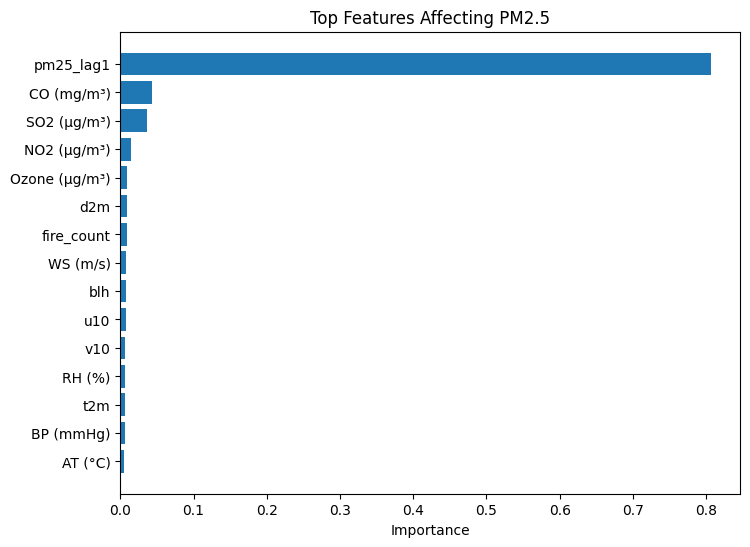

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': features_final,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

plt.figure(figsize=(8,6))
plt.barh(
    importance['Feature'][:15],
    importance['Importance'][:15]
)
plt.xlabel("Importance")
plt.title("Top Features Affecting PM2.5")
plt.gca().invert_yaxis()
plt.show()

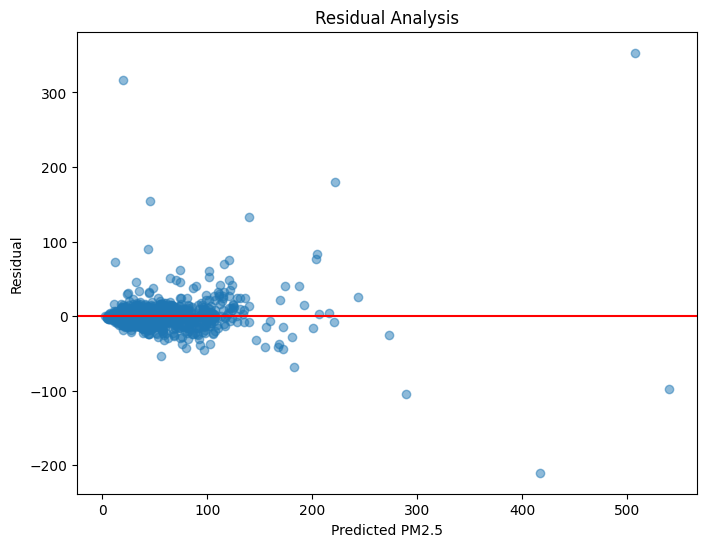

In [ ]:
residuals = y_test - pred

plt.figure(figsize=(8,6))
plt.scatter(pred, residuals, alpha=0.5)
plt.axhline(0, color='red')
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residual")
plt.title("Residual Analysis")
plt.show()

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

print("R2 =", r2_score(y_test, pred))

R2 = 0.8467944638762426


In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

pred = xgb.predict(X_test)

print("R2 =", r2_score(y_test, pred))
print("MAE =", mean_absolute_error(y_test, pred))
print("RMSE =", np.sqrt(mean_squared_error(y_test, pred)))

R2 = 0.8467944638762426
MAE = 8.416613393501505
RMSE = 18.819361141191532


In [ ]:
import joblib

joblib.dump(xgb, "pm25_xgboost_final.pkl")
joblib.dump(features_final, "features_final.pkl")

['features_final.pkl']

          Feature  Importance
19      pm25_lag1    0.685674
2      CO (mg/m³)    0.058598
11        city_id    0.028892
15            d2m    0.028624
1     SO2 (µg/m³)    0.023750
16             sp    0.023290
6        WS (m/s)    0.019999
10      dayofyear    0.015623
8       BP (mmHg)    0.012706
18     fire_count    0.012538
3   Ozone (µg/m³)    0.011451
5          RH (%)    0.011389
0     NO2 (µg/m³)    0.010002
17            blh    0.009962
12            u10    0.008708
14            t2m    0.008294
7         RF (mm)    0.008221
4         AT (°C)    0.007798
9           month    0.007358
13            v10    0.007123


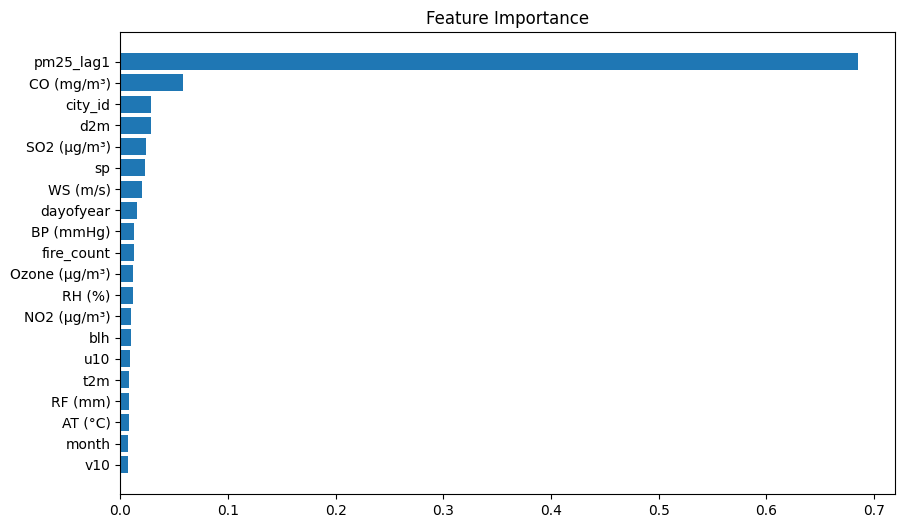

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': features_final,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))
plt.barh(
    importance['Feature'],
    importance['Importance']
)
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

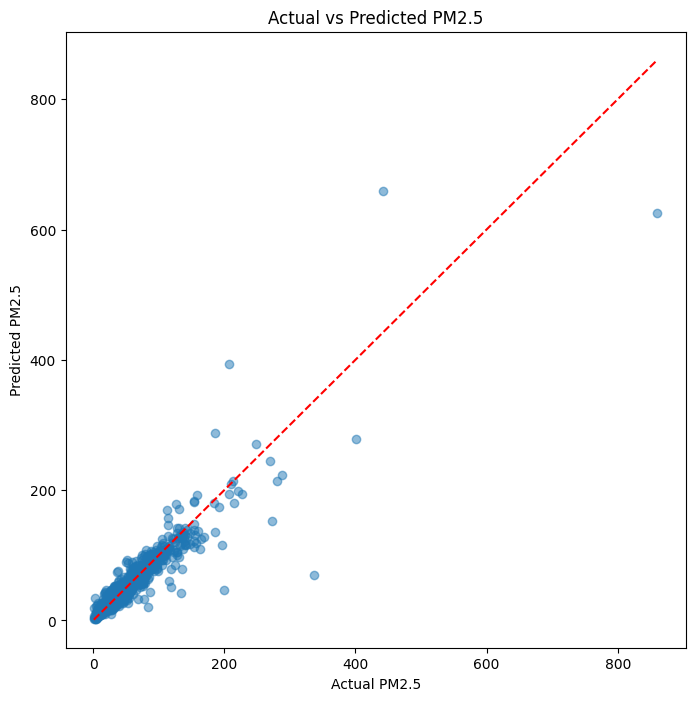

In [ ]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Actual vs Predicted PM2.5")

plt.show()

In [ ]:
merged_df['predicted_pm25'] = xgb.predict(
    merged_df[features_final]
)

merged_df[['City','Date','predicted_pm25']].head()

,City,Date,predicted_pm25
0,Agartala,2024-01-01,357.816772
1,Agartala,2024-01-02,84.119469
2,Agartala,2024-01-03,73.113136
3,Agartala,2024-01-04,70.977531
4,Agartala,2024-01-05,73.517784


In [ ]:
city_pm25 = (
    merged_df.groupby('City')['predicted_pm25']
    .mean()
    .reset_index()
)

city_pm25.head()

,City,predicted_pm25
0,Agartala,53.207691
1,Ahmedabad,57.132915
2,Amaravati,26.527391
3,Amritsar,55.763462
4,Baddi,63.132866


In [ ]:
!pip install folium

In [ ]:
from folium.plugins import HeatMap
import folium




In [ ]:
m = folium.Map(
    location=[22.5, 80],
    zoom_start=5
)

heat_data = [
    [row['lat'], row['lon'], row['predicted_pm25']]
    for _, row in city_pm25.iterrows()
]

HeatMap(
    heat_data,
    radius=25,
    blur=20,
    max_zoom=10
).add_to(m)

m

KeyError: 'lat'

In [ ]:
m.save("india_pm25_heatmap.html")

In [ ]:
def aqi_category(pm25):
    if pm25 <= 30:
        return "Good"
    elif pm25 <= 60:
        return "Satisfactory"
    elif pm25 <= 90:
        return "Moderate"
    elif pm25 <= 120:
        return "Poor"
    elif pm25 <= 250:
        return "Very Poor"
    else:
        return "Severe"

city_pm25["AQI"] = city_pm25["predicted_pm25"].apply(aqi_category)

In [ ]:
def get_color(pm25):
    if pm25 <= 30:
        return 'green'
    elif pm25 <= 60:
        return 'lightgreen'
    elif pm25 <= 90:
        return 'orange'
    elif pm25 <= 120:
        return 'red'
    elif pm25 <= 250:
        return 'purple'
    else:
        return 'darkred'

In [ ]:
m = folium.Map(location=[22.5,80], zoom_start=5)

for _, row in city_pm25.iterrows():

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=12,
        color=get_color(row['predicted_pm25']),
        fill=True,
        fill_color=get_color(row['predicted_pm25']),
        popup=f"""
        <b>{row['City']}</b><br>
        PM2.5: {row['predicted_pm25']:.1f}<br>
        AQI: {row['AQI']}
        """
    ).add_to(m)

m

In [ ]:
m.save("india_aqi_map.html")


In [ ]:
city_coords = {
    "Agartala": (23.8315, 91.2868),
    "Ahmedabad": (23.0225, 72.5714),
    "Amaravati": (16.5062, 80.6480),
    "Amritsar": (31.6340, 74.8723),
    "Baddi": (30.9578, 76.7914),
    "Bengaluru": (12.9716, 77.5946),
    "Bhubaneswar": (20.2961, 85.8245),
    "Chandigarh": (30.7333, 76.7794),
    "Chennai": (13.0827, 80.2707),
    "Dehradun": (30.3165, 78.0322),
    "Delhi": (28.6139, 77.2090),
    "Gangtok": (27.3389, 88.6065),
    "Guwahati": (26.1445, 91.7362),
    "Gurugram": (28.4595, 77.0266),
    "Hyderabad": (17.3850, 78.4867),
    "Imphal": (24.8170, 93.9368),
    "Jaipur": (26.9124, 75.7873),
    "Kohima": (25.6751, 94.1086),
    "Kolkata": (22.5726, 88.3639),
    "Lucknow": (26.8467, 80.9462),
    "Mumbai": (19.0760, 72.8777),
    "Nagpur": (21.1458, 79.0882),
    "Naharlagun": (27.1047, 93.6952),
    "Patna": (25.5941, 85.1376),
    "Raipur": (21.2514, 81.6296),
    "Shillong": (25.5788, 91.8933),
    "Srinagar": (34.0837, 74.7973),
    "Thiruvananthapuram": (8.5241, 76.9366)
}

In [ ]:
import rasterio
import pandas as pd
import os

results = []

folder = "HCHO"

for month in range(1, 13):

    tif_file = os.path.join(
        folder,
        f"HCHO_2024_Month_{month}.tif"
    )

    with rasterio.open(tif_file) as src:

        for city, (lat, lon) in city_coords.items():

            row, col = src.index(lon, lat)

            value = src.read(1)[row, col]

            results.append({
                "City": city,
                "Month": month,
                "HCHO": value
            })

city_hcho = pd.DataFrame(results)

city_hcho.head()

In [ ]:
city_hcho.to_csv(
    "city_hcho_2024.csv",
    index=False
)



In [ ]:
monthly_hcho = (
    city_hcho.groupby("City")["HCHO"]
    .mean()
    .sort_values(ascending=False)
)



In [ ]:
fire_df['acq_date'] = pd.to_datetime(
    fire_df['acq_date']
)

fire_df['Month'] = fire_df[
    'acq_date'
].dt.month

monthly_fire = (
    fire_df.groupby('Month')
    .size()
    .reset_index(name='Fire_Count')
)

In [ ]:
hcho_fire = city_hcho.merge(
    monthly_fire,
    on='Month',
    how='left'
)

hcho_fire.head()

In [ ]:
corr = hcho_fire[
    ['HCHO','Fire_Count']
].corr()

print(corr)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    hcho_fire['Fire_Count'],
    hcho_fire['HCHO'],
    alpha=0.5
)

plt.xlabel("Fire Count")
plt.ylabel("HCHO")

plt.title(
    "Relationship Between Fire Activity and HCHO"
)

plt.show()

In [ ]:
city_hcho.head()

In [ ]:
merged_hcho_fire = city_hcho.merge(
    monthly_fire,
    on="Month"
)


In [ ]:
corr = merged_hcho_fire["HCHO"].corr(
    merged_hcho_fire["Fire_Count"]
)



In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    merged_hcho_fire["Fire_Count"],
    merged_hcho_fire["HCHO"]
)

plt.xlabel("Fire Count")
plt.ylabel("HCHO")
plt.title("Fire Activity vs HCHO")

plt.show()

In [ ]:
hcho_hotspot = city_hcho.groupby("City")["HCHO"].mean().reset_index()

hcho_hotspot.head()

In [ ]:
hcho_hotspot["lat"] = hcho_hotspot["City"].map(
    {k:v[0] for k,v in city_coords.items()}
)

hcho_hotspot["lon"] = hcho_hotspot["City"].map(
    {k:v[1] for k,v in city_coords.items()}
)

hcho_hotspot.head()

In [ ]:
import folium

m = folium.Map(
    location=[22,79],
    zoom_start=5
)

for _, row in hcho_hotspot.iterrows():

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=row["HCHO"] * 100000,
        popup=f"{row['City']}<br>HCHO={row['HCHO']:.6f}",
        color="red",
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

m

In [ ]:
import rasterio
import numpy as np
import glob

files = sorted(glob.glob("HCHO/*.tif"))

arrays = []

for f in files:
    with rasterio.open(f) as src:
        arrays.append(src.read(1))

annual_hcho = np.mean(arrays, axis=0)

print(annual_hcho.shape)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(
    annual_hcho,
    cmap='jet'
)

plt.colorbar(label='HCHO')
plt.title("India Annual Mean HCHO 2024")

plt.show()

In [ ]:
plt.savefig("India_HCHO_Map.png", dpi=300)

In [ ]:
plt.savefig("India_HCHO_Map.png", dpi=300)

In [ ]:
plt.savefig("Fire_HCHO_Correlation.png", dpi=300)

In [ ]:
def pm25_to_aqi(pm):
    if pm <= 30:
        return "Good"
    elif pm <= 60:
        return "Satisfactory"
    elif pm <= 90:
        return "Moderate"
    elif pm <= 120:
        return "Poor"
    elif pm <= 250:
        return "Very Poor"
    else:
        return "Severe"

city_pm25["AQI_Category"] = city_pm25["predicted_pm25"].apply(pm25_to_aqi)

In [ ]:
import os
import rasterio
import pandas as pd

results = []

for month in range(1, 13):

    tif_file = f"NO2_2024_Month_{month}.tif"

    for root, dirs, files in os.walk("."):
        if tif_file in files:
            tif_path = os.path.join(root, tif_file)

            with rasterio.open(tif_path) as src:

                for city, (lat, lon) in city_coords.items():

                    row, col = src.index(lon, lat)

                    try:
                        value = src.read(1)[row, col]

                        results.append({
                            "City": city,
                            "Month": month,
                            "NO2": float(value)
                        })

                    except:
                        pass

city_no2 = pd.DataFrame(results)

print(city_no2.shape)
city_no2.head()

In [ ]:
import os
import rasterio
import pandas as pd

results = []

for month in range(1, 13):

    tif_file = f"SO2_2024_Month_{month}.tif"

    for root, dirs, files in os.walk("."):
        if tif_file in files:

            tif_path = os.path.join(root, tif_file)

            with rasterio.open(tif_path) as src:

                for city, (lat, lon) in city_coords.items():

                    row, col = src.index(lon, lat)

                    try:
                        value = src.read(1)[row, col]

                        results.append({
                            "City": city,
                            "Month": month,
                            "SO2": float(value)
                        })

                    except:
                        pass

city_so2 = pd.DataFrame(results)

print(city_so2.shape)
city_so2.head()

In [ ]:
import os
import rasterio
import pandas as pd

results = []

for month in range(1, 13):

    tif_file = f"CO_2024_Month_{month}.tif"

    for root, dirs, files in os.walk("."):
        if tif_file in files:

            tif_path = os.path.join(root, tif_file)

            with rasterio.open(tif_path) as src:

                for city, (lat, lon) in city_coords.items():

                    row, col = src.index(lon, lat)

                    try:
                        value = src.read(1)[row, col]

                        results.append({
                            "City": city,
                            "Month": month,
                            "CO": float(value)
                        })

                    except:
                        pass

city_co = pd.DataFrame(results)

print(city_co.shape)
city_co.head()

In [ ]:
satellite_db = (
    city_hcho
    .merge(city_no2, on=["City", "Month"])
    .merge(city_so2, on=["City", "Month"])
    .merge(city_co, on=["City", "Month"])
)

print(satellite_db.shape)

satellite_db.head()

In [ ]:
satellite_db.to_csv(
    "satellite_multi_pollutant_database.csv",
    index=False
)

print("Saved")

In [ ]:
required_cols = [
    'City',
    'Date',
    'PM2.5 (µg/m³)',
    'PM10 (µg/m³)',
    'NO (µg/m³)',
    'NO2 (µg/m³)',
    'NOx (ppb)',
    'NH3 (µg/m³)',
    'SO2 (µg/m³)',
    'CO (mg/m³)',
    'Ozone (µg/m³)',
    'AT (°C)',
    'RH (%)',
    'WS (m/s)',
    'WD (deg)',
    'RF (mm)',
    'BP (mmHg)',
    'SR (W/mt2)'
]

surface_db = combined_df[required_cols].copy()

print(surface_db.shape)
surface_db.head()

In [ ]:
surface_db_clean = surface_db.copy()

numeric_cols = surface_db_clean.select_dtypes(include='number').columns

for col in numeric_cols:
    surface_db_clean[col] = surface_db_clean[col].fillna(
        surface_db_clean[col].median()
    )

print(surface_db_clean.isnull().sum().sum())
print(surface_db_clean.shape)

In [ ]:
surface_db["Date"] = pd.to_datetime(surface_db["Date"])

surface_db["Month"] = surface_db["Date"].dt.month

monthly_surface = (
    surface_db.groupby(["City", "Month"])
    .mean(numeric_only=True)
    .reset_index()
)

print(monthly_surface.shape)
monthly_surface.head()

In [ ]:
final_db = monthly_surface.merge(
    satellite_db,
    on=["City", "Month"],
    how="inner"
)

print(final_db.shape)
final_db.head()

In [ ]:
final_db_clean = final_db.copy()

for col in final_db_clean.columns:
    if final_db_clean[col].dtype != "object":
        final_db_clean[col] = final_db_clean[col].fillna(
            final_db_clean[col].median()
        )

print(final_db_clean.isnull().sum().sum())

In [ ]:
print(final_db_clean.shape)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Target
y = final_db_clean["PM2.5 (µg/m³)"]

# Features
X = final_db_clean.drop(
    columns=[
        "City",
        "Month",
        "PM2.5 (µg/m³)"
    ]
)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² =", r2)
print("MAE =", mae)
print("RMSE =", rmse)

In [ ]:
X_scaled = scaler.transform(X)

print(X_scaled.shape)

In [ ]:
final_db["Pred_PM25"] = model.predict(X_scaled).flatten()

final_db[["City","Month","PM2.5 (µg/m³)","Pred_PM25"]].head()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    final_db["PM2.5 (µg/m³)"],
    final_db["Pred_PM25"],
    alpha=0.7
)

plt.plot(
    [final_db["PM2.5 (µg/m³)"].min(),
     final_db["PM2.5 (µg/m³)"].max()],
    [final_db["PM2.5 (µg/m³)"].min(),
     final_db["PM2.5 (µg/m³)"].max()],
    'r--'
)

plt.xlabel("Observed PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Observed vs Predicted PM2.5")

plt.show()

In [ ]:
final_db["Error"] = (
    final_db["Pred_PM25"]
    - final_db["PM2.5 (µg/m³)"]
)

plt.figure(figsize=(8,5))

plt.hist(
    final_db["Error"],
    bins=30
)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")

plt.show()

In [ ]:
final_db.to_csv("Final_MultiPollutant_Dataset_2024.csv", index=False)

print("Dataset saved")

In [ ]:
model.save("PM25_DeepLearning_Model.keras")

In [ ]:
import os
print(os.path.abspath("PM25_DeepLearning_Model.keras"))

In [ ]:
import joblib

joblib.dump(scaler, "PM25_Scaler.pkl")

In [ ]:
import os

for f in os.listdir():
    if f.endswith((".csv",".keras",".pkl")):
        print(f)

In [ ]:
def pm25_to_aqi(pm):

    if pm <= 30:
        return (50/30)*pm

    elif pm <= 60:
        return 50 + (pm-30)*(50/30)

    elif pm <= 90:
        return 100 + (pm-60)*(100/30)

    elif pm <= 120:
        return 200 + (pm-90)*(100/30)

    elif pm <= 250:
        return 300 + (pm-120)*(100/130)

    else:
        return 400 + (pm-250)*(100/130)

final_db["AQI"] = final_db["Pred_PM25"].apply(pm25_to_aqi)

final_db[["City","Month","Pred_PM25","AQI"]].head()

In [ ]:
print(final_db["AQI"].describe())

In [ ]:
final_db.to_csv(
    "Final_MultiPollutant_AQI_Dataset_2024.csv",
    index=False
)

In [ ]:
final_db[["City","Month","Pred_PM25","AQI"]].head()

In [ ]:
print(final_db["AQI"].describe())

In [ ]:
def aqi_category(aqi):

    if aqi <= 50:
        return "Good"

    elif aqi <= 100:
        return "Satisfactory"

    elif aqi <= 200:
        return "Moderate"

    elif aqi <= 300:
        return "Poor"

    elif aqi <= 400:
        return "Very Poor"

    else:
        return "Severe"


final_db["AQI_Category"] = final_db["AQI"].apply(aqi_category)

final_db[["City","Month","AQI","AQI_Category"]].head()

In [ ]:
final_db.to_csv(
    "Final_MultiPollutant_AQI_Dataset_2024.csv",
    index=False
)

print("Final dataset saved")

In [ ]:
print(len(city_coords))
print(list(city_coords.items())[:3])

In [ ]:
import pandas as pd

# Add coordinates
final_db["Latitude"] = final_db["City"].map(lambda x: city_coords[x][0])
final_db["Longitude"] = final_db["City"].map(lambda x: city_coords[x][1])

print(final_db.shape)
final_db[["City","Latitude","Longitude"]].head()

In [ ]:
import folium

month = 12   # Change month here

map_df = final_db[final_db["Month"] == month]

m = folium.Map(
    location=[22.5, 80],
    zoom_start=5
)

for _, row in map_df.iterrows():

    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=8,
        popup=f"""
        City: {row['City']}<br>
        AQI: {row['AQI']:.1f}<br>
        Category: {row['AQI_Category']}
        """,
        fill=True
    ).add_to(m)

m

In [ ]:
m.save("India_AQI_Map_December_2024.html")

print("Map saved")

In [ ]:
final_db.to_csv(
    "Final_MultiPollutant_AQI_Dataset_2024.csv",
    index=False
)

print("Dataset exported successfully")

In [ ]:
final_db["AQI"] = final_db["Pred_PM25"].apply(pm25_to_aqi)

In [ ]:
final_db[["City","Month","Pred_PM25","AQI"]].head()

In [ ]:
import folium

month = 12

map_df = final_db[final_db["Month"] == month]

def get_color(aqi):
    if aqi <= 50:
        return "green"
    elif aqi <= 100:
        return "yellow"
    elif aqi <= 200:
        return "orange"
    elif aqi <= 300:
        return "red"
    elif aqi <= 400:
        return "purple"
    else:
        return "darkred"

m = folium.Map(
    location=[22.5, 80],
    zoom_start=5
)

for _, row in map_df.iterrows():

    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=10,
        color=get_color(row["AQI"]),
        fill=True,
        fill_color=get_color(row["AQI"]),
        fill_opacity=0.8,
        popup=f"""
        City: {row['City']}<br>
        AQI: {row['AQI']:.1f}<br>
        PM2.5: {row['Pred_PM25']:.1f}
        """
    ).add_to(m)

m

In [ ]:
m.save("India_Surface_AQI_Dec2024.html")

In [ ]:
final_db.to_csv(
    "Final_Surface_AQI_Dataset_2024.csv",
    index=False
)

In [ ]:
#testing the model 
import pandas as pd

dummy = pd.DataFrame([{
    'HCHO': 0.00018,
    'NO2': 0.00012,
    'SO2': 0.00035,
    'CO': 0.045,

    'NO (µg/m³)': 12,
    'NO2 (µg/m³)': 20,
    'NOx (ppb)': 35,
    'NH3 (µg/m³)': 15,
    'SO2 (µg/m³)': 18,
    'CO (mg/m³)': 1.2,
    'Ozone (µg/m³)': 55,

    'AT (°C)': 32,
    'RH (%)': 70,
    'WS (m/s)': 2.5,
    'WD (deg)': 180,
    'RF (mm)': 0,
    'BP (mmHg)': 750,
    'SR (W/mt2)': 180,
    'Month': 6
}])

In [ ]:
dummy_scaled = scaler.transform(dummy)

In [ ]:
dummy = pd.DataFrame([0]*len(X.columns), index=X.columns).T

print(dummy.columns)

In [ ]:
dummy.loc[0, 'HCHO'] = 0.00018
dummy.loc[0, 'NO2'] = 0.00012
dummy.loc[0, 'SO2'] = 0.00035
dummy.loc[0, 'CO'] = 0.045

dummy.loc[0, 'PM10 (µg/m³)'] = 120
dummy.loc[0, 'NO (µg/m³)'] = 12
dummy.loc[0, 'NO2 (µg/m³)'] = 20
dummy.loc[0, 'NOx (ppb)'] = 35
dummy.loc[0, 'NH3 (µg/m³)'] = 15
dummy.loc[0, 'SO2 (µg/m³)'] = 18
dummy.loc[0, 'CO (mg/m³)'] = 1.2
dummy.loc[0, 'Ozone (µg/m³)'] = 55
dummy.loc[0, 'AT (°C)'] = 32
dummy.loc[0, 'RH (%)'] = 70
dummy.loc[0, 'WS (m/s)'] = 2.5
dummy.loc[0, 'WD (deg)'] = 180
dummy.loc[0, 'RF (mm)'] = 0
dummy.loc[0, 'BP (mmHg)'] = 750
dummy.loc[0, 'SR (W/mt2)'] = 180

In [ ]:
dummy = pd.DataFrame(
    np.zeros((1, len(X.columns))),
    columns=X.columns,
    dtype=float
)

In [ ]:
dummy.loc[0, 'HCHO'] = 0.00018
dummy.loc[0, 'NO2'] = 0.00012
dummy.loc[0, 'SO2'] = 0.00035
dummy.loc[0, 'CO'] = 0.045

dummy.loc[0, 'PM10 (µg/m³)'] = 120
dummy.loc[0, 'NO (µg/m³)'] = 12
dummy.loc[0, 'NO2 (µg/m³)'] = 20
dummy.loc[0, 'NOx (ppb)'] = 35
dummy.loc[0, 'NH3 (µg/m³)'] = 15
dummy.loc[0, 'SO2 (µg/m³)'] = 18
dummy.loc[0, 'CO (mg/m³)'] = 1.2
dummy.loc[0, 'Ozone (µg/m³)'] = 55
dummy.loc[0, 'AT (°C)'] = 32
dummy.loc[0, 'RH (%)'] = 70
dummy.loc[0, 'WS (m/s)'] = 2.5
dummy.loc[0, 'WD (deg)'] = 180
dummy.loc[0, 'RF (mm)'] = 0
dummy.loc[0, 'BP (mmHg)'] = 750
dummy.loc[0, 'SR (W/mt2)'] = 180

In [ ]:

dummy_scaled = scaler.transform(dummy)

pred = model.predict(dummy_scaled)

print("Predicted PM2.5 =", pred[0][0])

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import glob

hcho_files = sorted(glob.glob("*HCHO*.tif"))

hcho_stack = []

for f in hcho_files:
    with rasterio.open(f) as src:
        data = src.read(1)
        data = np.where(data < 0, np.nan, data)
        hcho_stack.append(data)

annual_hcho = np.nanmean(hcho_stack, axis=0)

plt.figure(figsize=(10,6))
plt.imshow(annual_hcho, cmap="hot")
plt.colorbar(label="HCHO")
plt.title("Annual Mean HCHO Hotspots (2024)")
plt.show()

In [ ]:
print(len(hcho_stack))

for i, arr in enumerate(hcho_stack[:3]):
    print(i, arr.shape)

print(type(annual_hcho))
print(annual_hcho.shape)

In [ ]:
with rasterio.open(hcho_files[0]) as src:
    test = src.read()

print(test.shape)

In [ ]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".tif"):
            print(file)

In [ ]:
import os

hcho_files = []

for root, dirs, files in os.walk("."):
    for file in files:
        if "HCHO" in file and file.endswith(".tif"):
            hcho_files.append(os.path.join(root, file))

print("Number of HCHO files:", len(hcho_files))
print(hcho_files[:5])

In [ ]:
import os

hcho_files = []

for root, dirs, files in os.walk("."):
    for file in files:
        if file.startswith("HCHO_") and file.endswith(".tif"):
            hcho_files.append(os.path.join(root, file))

print("HCHO files found:", len(hcho_files))
print(hcho_files[:3])

In [ ]:
import rasterio
import numpy as np

hcho_stack = []

for f in sorted(hcho_files):
    with rasterio.open(f) as src:
        data = src.read(1)

        # remove invalid values
        data = np.where(data < 0, np.nan, data)

        hcho_stack.append(data)

print("Number of rasters:", len(hcho_stack))
print("Raster shape:", hcho_stack[0].shape)

annual_hcho = np.nanmean(np.stack(hcho_stack), axis=0)

print("Annual HCHO shape:", annual_hcho.shape)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.imshow(annual_hcho, cmap="hot")
plt.colorbar(label="HCHO")
plt.title("Annual Mean HCHO Hotspots (2024)")
plt.show()

In [ ]:
import os

print(os.listdir("HCHO"))

In [ ]:
burning_months = [
    "HCHO/HCHO_2024_Month_10.tif",
    "HCHO/HCHO_2024_Month_11.tif",
    "HCHO/HCHO_2024_Month_12.tif",
    "HCHO/HCHO_2024_Month_1.tif"
]

burn_stack = []

for f in burning_months:
    with rasterio.open(f) as src:
        data = src.read(1)
        data = np.where(data < 0, np.nan, data)
        burn_stack.append(data)

burn_hcho = np.nanmean(np.stack(burn_stack), axis=0)

plt.figure(figsize=(12,6))
plt.imshow(burn_hcho, cmap="hot")
plt.colorbar(label="HCHO")
plt.title("Biomass Burning Season HCHO Hotspots")
plt.show()

In [ ]:
print(daily_fire.columns)
print(daily_fire.head())

In [ ]:
print([v for v in globals().keys() if "fire" in v.lower()])

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.scatter(
    fire_df["longitude"],
    fire_df["latitude"],
    s=1,
    alpha=0.3,
    c="red"
)

plt.title("VIIRS Fire Hotspots (2024)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
plt.figure(figsize=(10,8))

plt.hexbin(
    fire_df["longitude"],
    fire_df["latitude"],
    gridsize=50,
    cmap="hot"
)

plt.colorbar(label="Fire Density")
plt.title("Fire Hotspot Density Map (2024)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [ ]:
print(fire_df.columns)
fire_df.head()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

hb = plt.hexbin(
    fire_df["longitude"],
    fire_df["latitude"],
    gridsize=60,
    C=fire_df["frp"],
    reduce_C_function=sum,
    cmap="hot",
    mincnt=1
)

plt.colorbar(hb, label="Fire Radiative Power (FRP)")
plt.title("Major Biomass Burning Source Regions (VIIRS 2024)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [ ]:
burning_fire = fire_df[fire_df["Month"].isin([3,4,5])]
plt.figure(figsize=(10,8))

hb = plt.hexbin(
    burning_fire["longitude"],
    burning_fire["latitude"],
    gridsize=60,
    C=burning_fire["frp"],
    reduce_C_function=sum,
    cmap="hot",
    mincnt=1
)

plt.colorbar(hb, label="Fire Radiative Power (FRP)")
plt.title("Biomass Burning Season Fire Hotspots (Mar-May 2024)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()